# Домашнее задание 3 KNN

## Загрузка датасета и нужных библиотек

В этом домашнем задании я анализирую датасет сухих зерен с 7 классами

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
import pandas as pd

df = pd.read_excel('Dry_Bean_Dataset.xlsx')

print("РАЗМЕР ДАТАСЕТА")
print(f"Строк: {df.shape[0]}, Признаков: {df.shape[1] - 1}\n") # -1 потому что последняя колонка это таргет



РАЗМЕР ДАТАСЕТА
Строк: 13611, Признаков: 16



In [21]:
from sklearn.preprocessing import LabelEncoder

# кодируем
le = LabelEncoder()
df['y'] = le.fit_transform(df['Class'])
df = df.drop('Class', axis=1)

In [19]:
print("БАЛАНС КЛАССОВ")
print(df['y'].value_counts())

# Смотрим первые 5 строк
df.head()

БАЛАНС КЛАССОВ
y
3    3546
6    2636
5    2027
4    1928
2    1630
0    1322
1     522
Name: count, dtype: int64


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,y
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,5


Можно видеть классов всего 7

## EDA анализ

In [5]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

С первого взгляда можно узнать следующую информацию:
- Размер датасета - 13611 строк и 16 колонка. (датасет средний)
- Типы признаков - числовые (float64 и int64)
- Таргет принимает значения текстовые всего 7 классов
- Нет дубликатов
- Нет пропусков (всех значений 13611, как и самих строк), нет скрытых пропусков
- Есть дисбаланс классов 

Text(0.5, 1.0, 'Корреляция признаков (Мультиколлинеарность)')

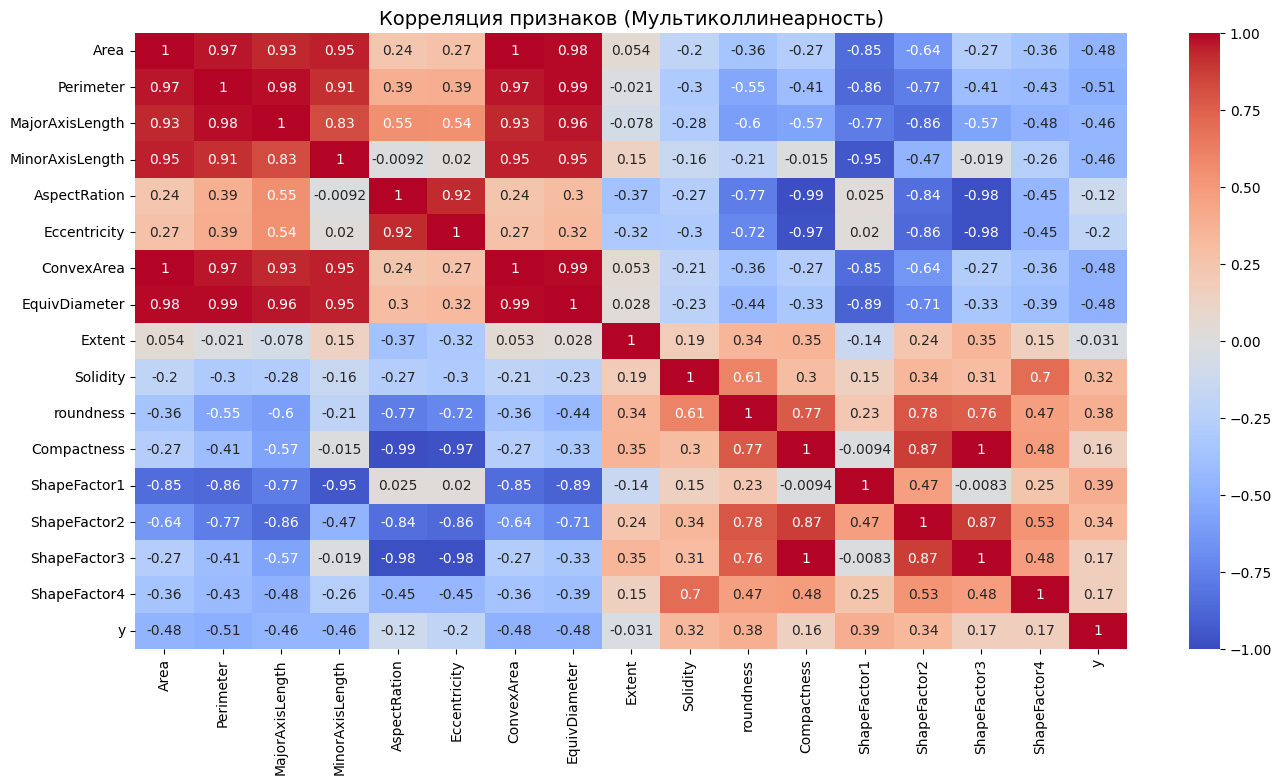

In [23]:
plt.figure(figsize=(16, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Корреляция признаков (Мультиколлинеарность)", fontsize=14)

Как можно заметить, есть признаки, которые сильно коррелируют между друг другом. Буду думать, очищать ли от некоторых признаков. Ещё отмечу, что нету признаков, которые прям сильно коррелируют с таргетом. Но корреляция заметна.

По describe можно уже визуально отметить, в каких колонках имеются выбросы. Я не буду строить для всех boxplot, а только для тех, где я правда заметила заметный выброс (в уме посчитала IQR и так далее)

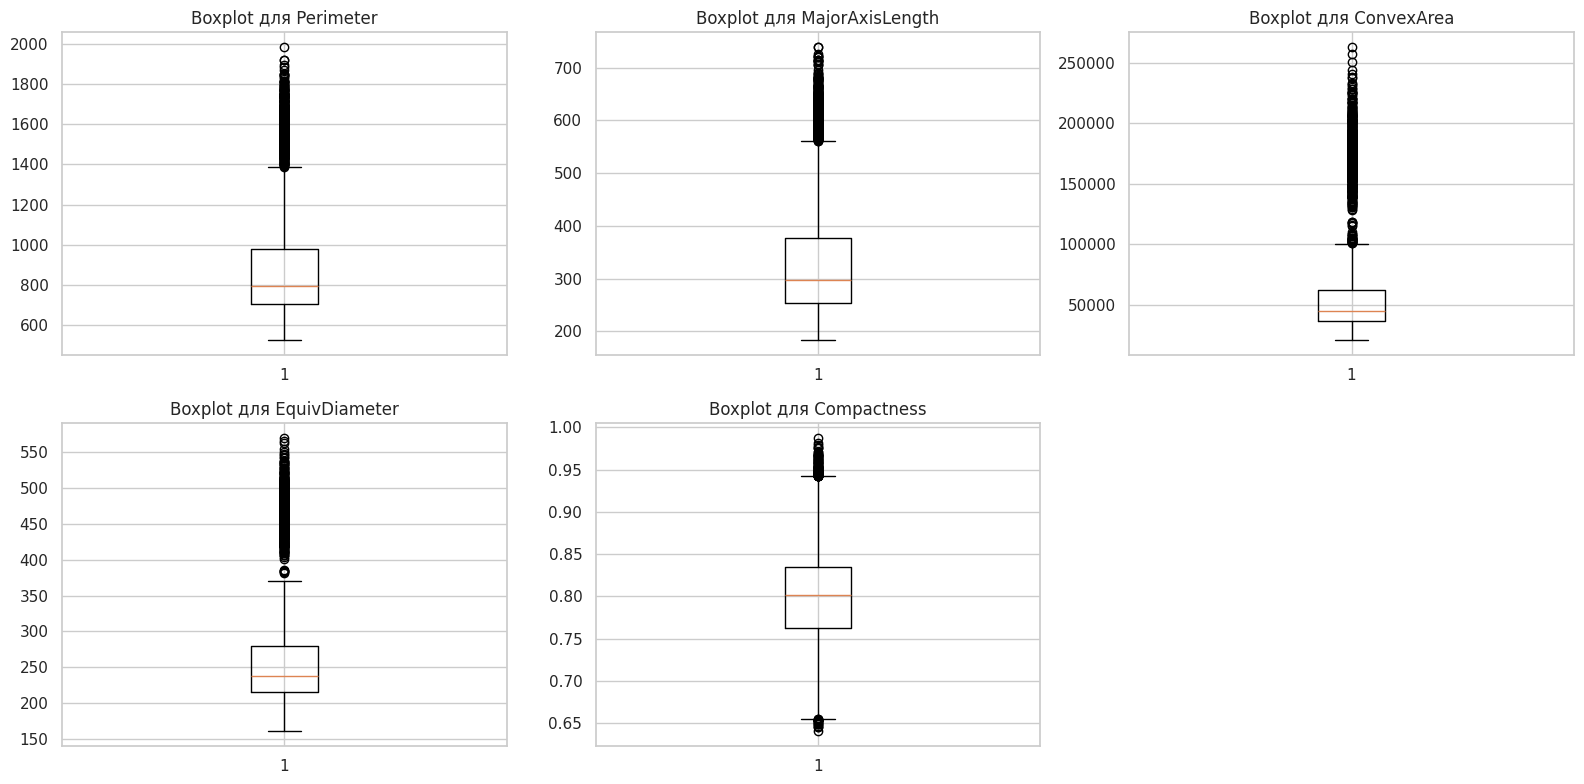

In [2]:
suspicious_features = ['Perimeter', 'MajorAxisLength', 'ConvexArea', 'EquivDiameter', 'Compactness']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))
for i, feature in enumerate(suspicious_features):
    plt.subplot(2, 3, i + 1)
    plt.boxplot(df[feature])
    plt.title(f'Boxplot для {feature}')

plt.tight_layout()
plt.show()

Как можно заметить, выбросы есть, и достаточно не мало. С чем это связано непонятно. Можно посмотреть по классам есть ли выбросы (Perimeter например)

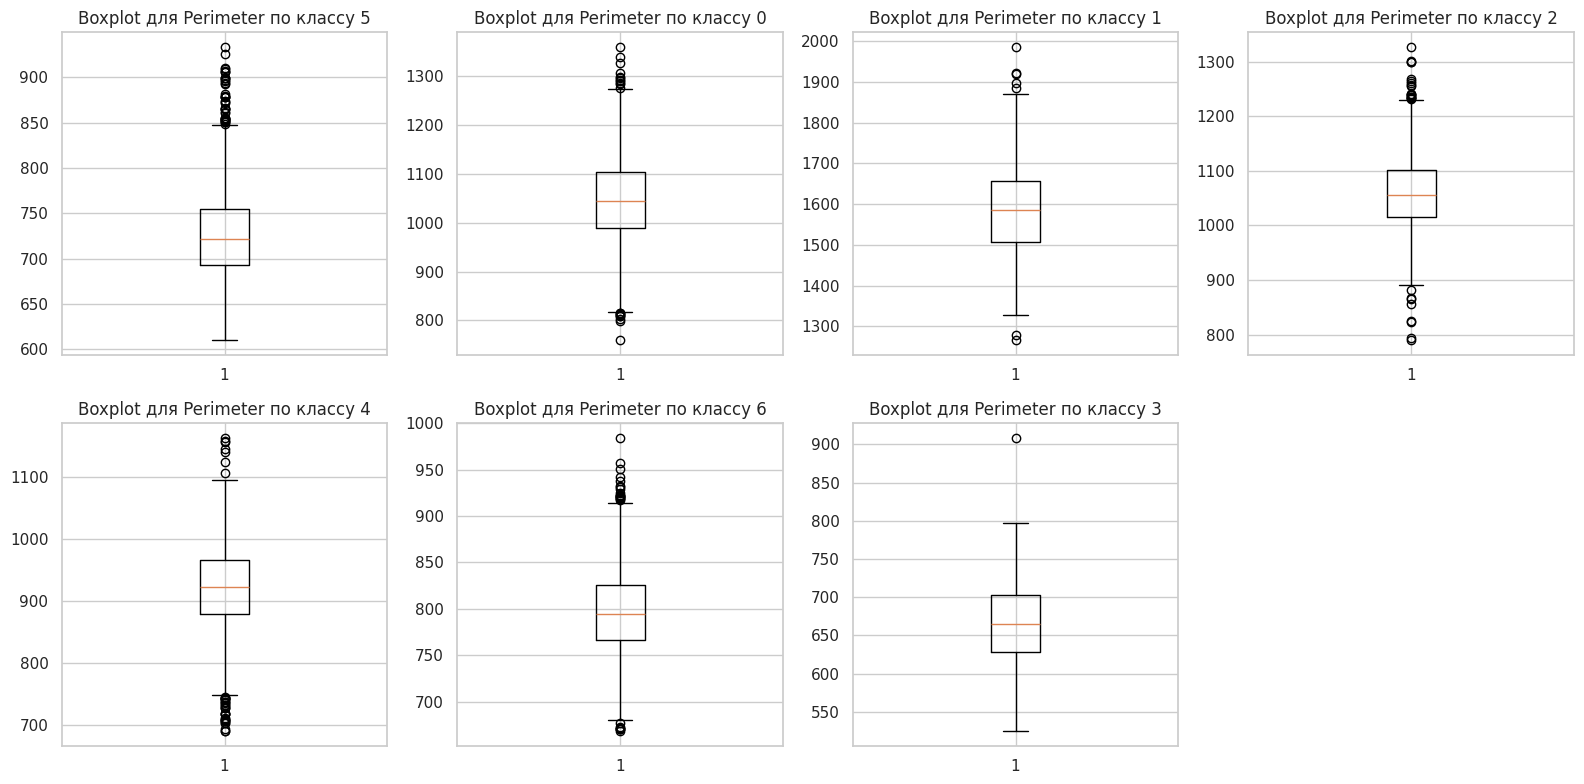

In [18]:
feature = 'Perimeter'

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))
for i, cls in enumerate(df['y'].unique().tolist()):
    plt.subplot(2, 4, i + 1)
    plt.boxplot(df[df['y'] == cls][feature])
    plt.title(f'Boxplot для {feature} по классу {cls}')

plt.tight_layout()
plt.show()

Можно заметить, что для некоторых классов диапазоны совпадают почти (для класса 0 и 2 например),  однако классы в основном имеют разные диапазоны, и их выбросы (я подозреваю), могут путать модель чтобы не давать правильные классы. Тем не менее радует тенденция, что для разных классов характерны разные значения (что для одних выброс, для других является медианой).

## Обработка данных и обучение модели

У нас нету дубликатов или пропусков. Чистить нечего. Надо лишь разделить данные. Обязательно использовать stratify=y так как это позволит сохранить равные пропопорции в train и test.

In [23]:
from sklearn.model_selection import train_test_split

seed = 42
X = df.drop(columns=['y'])
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)

### 1. Исследование влияния масштабирования

Давайте сначала вообще не будем масштабировать данные. Посмотрим, что выдаст модель

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score, recall_score

param_grid = {
    # Перебираем соседей (по нечетным числам, чтобы не было паритета)
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    # Битва метрик
    'knn__metric': ['euclidean', 'manhattan'],
}

my_pipe = Pipeline([
    ('scaler', 'passthrough'), 
    ('knn', KNeighborsClassifier(weights='uniform'))
])

grid_search = GridSearchCV(
    my_pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True,
    verbose=3
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры модели:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f"\nТочность на тестовой выборке: {test_accuracy:.4f}")

y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
print(f"F1 - {f1:.4f}")
print(f"Recall - {recall:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.853, test=0.735) total time=   0.1s
[CV 2/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.848, test=0.710) total time=   0.1s
[CV 3/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.851, test=0.722) total time=   0.1s
[CV 4/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.852, test=0.713) total time=   0.1s
[CV 1/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.805, test=0.730) total time=   0.1s
[CV 5/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.852, test=0.704) total time=   0.2s
[CV 2/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.804, test=0.715) total time=   0.1s
[CV 3/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.804, test=0.720) total time=   0.1s
[CV 4/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.810

Окей. Допустим. Теперь сделаем тоже самое, но уже с масштабированием

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score, recall_score

param_grid = {
    # Перебираем соседей (по нечетным числам, чтобы не было паритета)
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45],
    # Битва метрик
    'knn__metric': ['euclidean', 'manhattan'],
}

my_pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsClassifier(weights='uniform'))
])

grid_search = GridSearchCV(
    my_pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True,
    verbose=3
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры модели:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f"\nТочность на тестовой выборке: {test_accuracy:.4f}")

y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
print(f"F1 - {f1:.4f}")
print(f"Recall - {recall:.4f}")

Fitting 5 folds for each of 44 candidates, totalling 220 fits
[CV 1/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.950, test=0.928) total time=   0.1s
[CV 2/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.950, test=0.913) total time=   0.1s
[CV 3/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.952, test=0.916) total time=   0.1s
[CV 4/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.951, test=0.915) total time=   0.1s
[CV 5/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.948, test=0.916) total time=   0.1s
[CV 1/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.941, test=0.933) total time=   0.1s
[CV 2/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.942, test=0.918) total time=   0.1s
[CV 3/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.943, test=0.918) total time=   0.1s
[CV 4/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.94

Как можем заметить, метрики действиетельно подскочили. Даже можем заметить, что победила метрика Евклида во втором случае (которая больше штрафует большие значения), а в первом случае Манхеттена (которая меньше штрафует большие значения). Дело в том, что разброс и среднее у каждого признака очень разная. Разные диапазоны. Разница 33 года и 34 года не такая же, как разница между кальцием ионизированным в крови 1.15 и 2.15 (2.15 это очень большой уровень). Поэтому надо постараться привести все величины как бы к одной с помощью масштабированием

Ответы на вопросы:
- Почему масштабирование важно? - Каждый признак имеет свой диапазон значений, среднее и разброс. Если для одного признака разница на 1 это немного, то для другого это будет определять норма это или нет.
- Почему нельзя подбирать параметры под тестовую метрику - потому что это нечестно. Если мы оцениваем, как модель будет вести себя с новыми данными, то модель вообще при обучении и валидации не должна вообще подсматривать туда, иначе мы получим предвзятые результаты. На тестовую метрику нужно смотреть лишь один раз: в конце при оценке качества модели.

### 2. Влияние количества соседей и метрик

Построим график зависимости train score и test score

In [44]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)

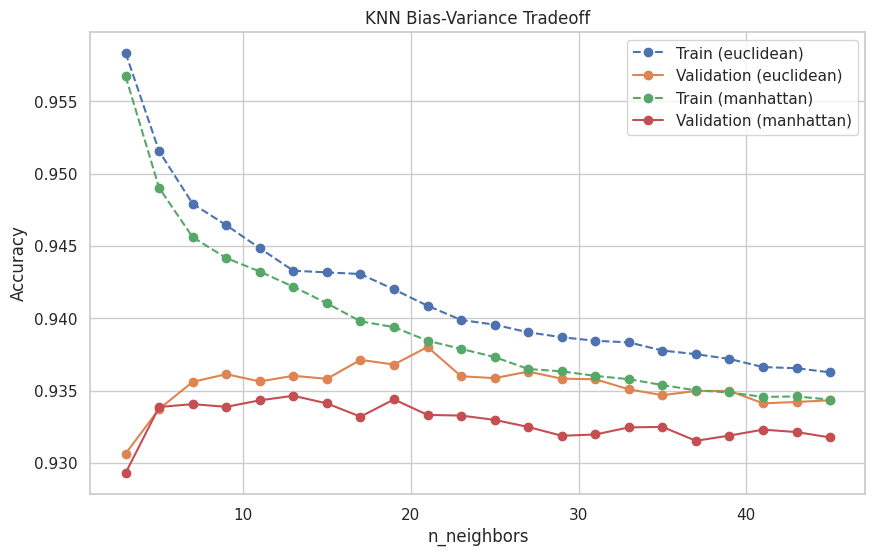

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10,6))

for metric in results['param_knn__metric'].unique():
    subset = results[results['param_knn__metric'] == metric]

    plt.plot(
        subset['param_knn__n_neighbors'],
        subset['mean_train_score'],
        '--o',
        label=f'Train ({metric})'
    )

    plt.plot(
        subset['param_knn__n_neighbors'],
        subset['mean_test_score'],
        '-o',
        label=f'Validation ({metric})'
    )

plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.title('KNN Bias-Variance Tradeoff')
plt.legend()
plt.show()

Можно заметить, что при слишком маленьком количестве соседей наблюдается переобучение. С ростом оно уменьшается. А test score сначала потихоньку рос, а потом медленно начал падать (хоть не сильно)

Поведение двух этих метрик схоже. Но Манхеттен заметно хуже себя показывает. Евклид больше штрафует за большие расстояния, как известно. Скорее всего, Евклид позволяет лучше обозначить границы классов. Ведь как мы видим, что для разного класса один признак принимает совершенно разные значения. То что для одного класса является выбросом, для другого класса это может быть медианой. Из-за этого Манхеттенская метрика может больше путать классы. Но это лишь мое мнение:)

Аналогично можно посмотреть, что происходит с F1 маcro. Здесь уже идет подбор по этой метрике

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score, recall_score

param_grid = {
    # Перебираем соседей (по нечетным числам, чтобы не было паритета)
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45],
    # Битва метрик
    'knn__metric': ['euclidean', 'manhattan'],
}

my_pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsClassifier(weights='uniform'))
])

grid_search = GridSearchCV(
    my_pipe,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True,
    verbose=3
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры модели:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f"\nAccuracy на тестовой выборке: {test_accuracy:.4f}")

y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
print(f"F1 - {f1:.4f}")
print(f"Recall - {recall:.4f}")

Fitting 5 folds for each of 44 candidates, totalling 220 fits
[CV 1/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.959, test=0.938) total time=   2.6s
[CV 2/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.958, test=0.928) total time=   2.6s
[CV 3/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.960, test=0.930) total time=   0.1s
[CV 4/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.959, test=0.926) total time=   0.1s
[CV 5/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=0.957, test=0.932) total time=   0.1s
[CV 1/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.951, test=0.942) total time=   0.2s
[CV 2/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.951, test=0.932) total time=   0.1s
[CV 3/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.952, test=0.933) total time=   0.1s
[CV 4/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=0.95

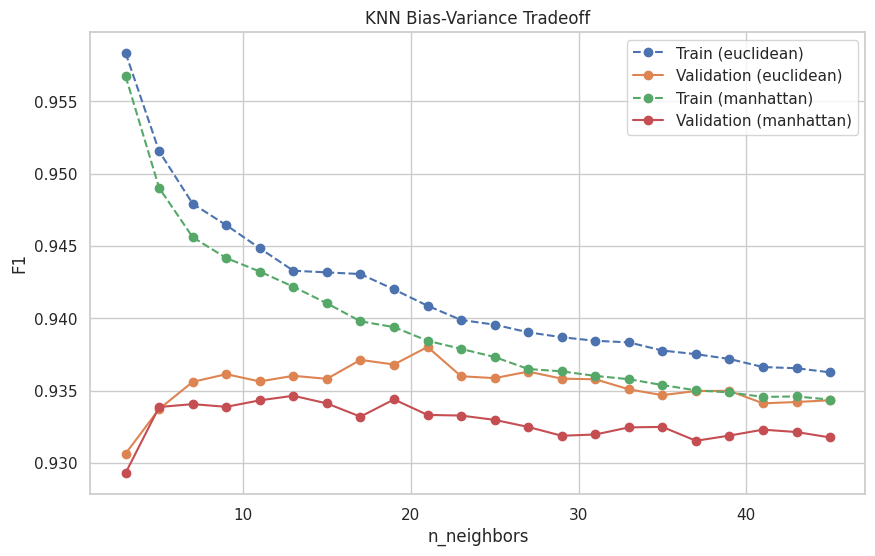

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10,6))
colors = ['green', 'red']
for metric, color in zip(results['param_knn__metric'].unique(), colors):
    subset = results[results['param_knn__metric'] == metric]

    plt.plot(
        subset['param_knn__n_neighbors'],
        subset['mean_train_score'],
        '--o',
        label=f'Train ({metric})'
    )

    plt.plot(
        subset['param_knn__n_neighbors'],
        subset['mean_test_score'],
        '-o',
        label=f'Validation ({metric})'
    )

plt.xlabel('n_neighbors')
plt.ylabel('F1')
plt.title('KNN Bias-Variance Tradeoff')
plt.legend()
plt.show()

Эта же тенденция сохраняется и для f1 macro. Сначала происходит рост, а с ростом соседей происходит спад тестовой метрики.

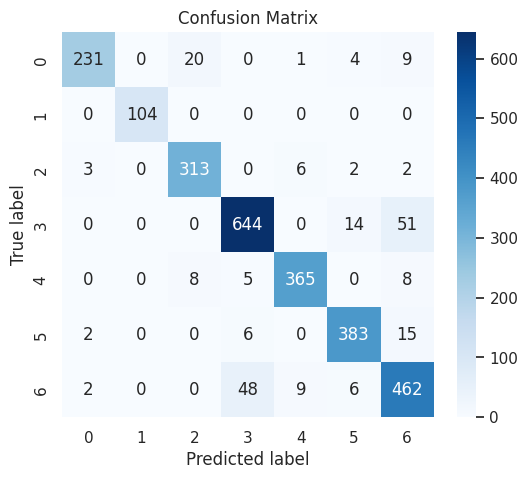

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.show()

Интересно, что самый редкий класс 1 вообще не путают. Больше всего путаницы между классамми 3 и 6. Интересно, запомним.

### 3. Влияние весов на качество модели

То что было выше было с uniform весами. А что если будет distance (больший вес получают те кто ближе)

Проведем аналогичные эксперименты

In [84]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score, recall_score

param_grid = {
    # Перебираем соседей (по нечетным числам, чтобы не было паритета)
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45],
    # Битва метрик
    'knn__metric': ['euclidean', 'manhattan'],
}

my_pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsClassifier(weights='distance'))
])

grid_search = GridSearchCV(
    my_pipe,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True,
    verbose=3
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры модели:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f"\nAccuracy на тестовой выборке: {test_accuracy:.4f}")

y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
print(f"F1 - {f1:.4f}")
print(f"Recall - {recall:.4f}")

Fitting 5 folds for each of 44 candidates, totalling 220 fits
[CV 2/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=1.000, test=0.929) total time=   0.1s
[CV 1/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=1.000, test=0.937) total time=   0.1s
[CV 4/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=1.000, test=0.925) total time=   0.1s
[CV 3/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=1.000, test=0.930) total time=   0.1s
[CV 5/5] END knn__metric=euclidean, knn__n_neighbors=3;, score=(train=1.000, test=0.931) total time=   0.1s
[CV 1/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=1.000, test=0.942) total time=   0.1s
[CV 2/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=1.000, test=0.935) total time=   0.1s
[CV 3/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=1.000, test=0.933) total time=   0.1s
[CV 4/5] END knn__metric=euclidean, knn__n_neighbors=5;, score=(train=1.00

Можно заметить следующее. При distance train абсолютно правильно угадывается (что не удивительно, ведь по логике класс должен совпасть с объектом, раз чем ближе объект, тем больше вес имеет). Плюс метрики чуточку выросли. Все-таки в нашем случае если учитывать насколько близок объект, происходит более точное определение. Например это может помочь для определения более редких классов.

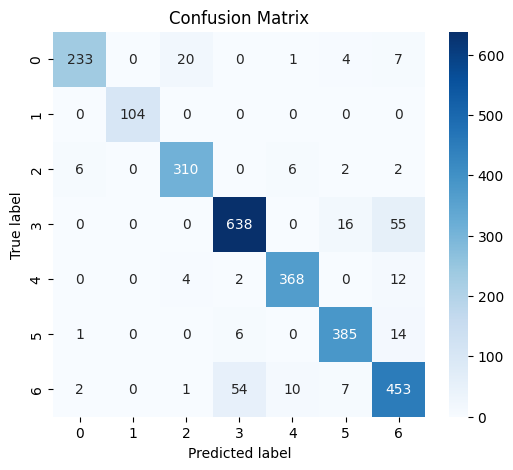

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.show()

В confussion matrix мы видим интересную картину. Если сравнивать с предыдущей матрицей, то для класса 0 (он второй по редкости класс), класса 4  слегка улучшилась картина. Однако для класса 3, 6 (более частых), 5 ухудшилась напротив. И для класа 2 тоже ухудшилась (хоть частота не самая большая, скорее где-то по середине). Решена проблема в сторону более малочисленных классов, и то не всех. 

<img src="image-20260428-130237.png" width="50" align="" />

### Экспериментальная матрика для обучения: mahalobis

Попробуем более умно учитывать расстояния, не только сами меры расстояния, но и облака точек. Что я имею в виду.
Пусть у нас есть Боря который ростом 195 см и весом 90 кг (нормальный человек), Витя ростом 185 см и весом 50 кг (странный человек). И есть Аня ростом 165 см и весом 60 кг. Если считать по метрике Евклида, то Аня ближе к Вите, чем к Боре. Однако Аня вообще-то имеет совершенно обычные среднестатистические параметры, в отличие от Вити. Как в этом случае надо измерять расстояния?
Standard Scaler делает вот такую вещь: центрирует к нулю облако и делает один и тот же разброс по осям x, y. А что если облако точек немного наклонено по диагонали. Как на рисунке ниже

<img src="image-20260428-132039.png" width="" align="" />

Как можно заметить, после standard Scaler облако снова вытянуто в диагональ. И снова Аня ближе к Вите, чем к Боре, хотя это абсурд. Поэтому есть другой подход. Сделать линейные преобразования таким образом, чтобы облако точек превратилось в шарик. Идея: найти главные направления, повернуть так, чтобы они совпали с осями, и отмасштабировать. Так получится шарик, где можно объективно искать расстояние Евклида.

<img src="image-20260428-132615.png" width="" align="" />

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score, recall_score

X_train_scaled = StandardScaler().fit_transform(X_train)
VI = np.linalg.inv(np.cov(X_train_scaled.T))

param_grid = {
    'knn__n_neighbors': [5, 11, 17, 23, 31, 41],
    'knn__weights': ['distance', 'uniform']
}

my_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        metric='mahalanobis',
        metric_params={'VI': VI},
        weights='distance',
        algorithm='brute'
    ))
])

grid_search = GridSearchCV(
    my_pipe, param_grid, cv=5, scoring='accuracy',
    n_jobs=-1, return_train_score=True, verbose=3
)
grid_search.fit(X_train, y_train)

print("Лучшие параметры модели:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f"\nAccuracy на тестовой выборке: {test_accuracy:.4f}")

y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
print(f"F1 - {f1:.4f}")
print(f"Recall - {recall:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END knn__n_neighbors=5, knn__weights=distance;, score=(train=1.000, test=0.933) total time=   1.4s
[CV 2/5] END knn__n_neighbors=5, knn__weights=distance;, score=(train=1.000, test=0.914) total time=   1.5s
[CV 4/5] END knn__n_neighbors=5, knn__weights=distance;, score=(train=1.000, test=0.917) total time=   1.4s
[CV 3/5] END knn__n_neighbors=5, knn__weights=distance;, score=(train=1.000, test=0.915) total time=   1.6s
[CV 5/5] END knn__n_neighbors=5, knn__weights=distance;, score=(train=1.000, test=0.928) total time=   1.5s
[CV 1/5] END knn__n_neighbors=5, knn__weights=uniform;, score=(train=0.939, test=0.932) total time=   1.5s
[CV 2/5] END knn__n_neighbors=5, knn__weights=uniform;, score=(train=0.944, test=0.914) total time=   1.5s
[CV 3/5] END knn__n_neighbors=5, knn__weights=uniform;, score=(train=0.942, test=0.914) total time=   1.5s
[CV 5/5] END knn__n_neighbors=5, knn__weights=uniform;, score=(train=0.942, te

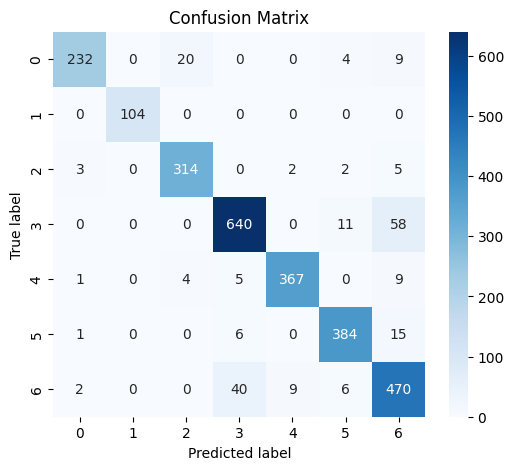

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.show()

Можно заметить, что метрики слегка улучшились, но не сильно. Путаницы между классами 3 и 6 стало слегка меньше и сами эти классы стали путать меньше. Для класса 2 почти не уменьшились путаницы. Для класса 4 слегка увеличились путаницы. Поэтому можно заключить то, что ситуация слегка улучшилась, но не слишком. Для определения разных классов, лучшим образом сработали совершенно разные метрики. Стоит ещё признать то, что для класса 3 и 6 реально много сходств. Поэтому не всегда просто их различить. В общем сработала лучше всего метрика эта экспериментальная

## Выводы:
- Масштабирование для knn очень важно
- Оптимальное количество соседей находится где-то посередине (слишком мало - большое переобучение, слишком много - ниже метрики)
- Лучше всего сработала метрика Евклида (позволяющая находить более типичные без выбросов объекты).
- Но самая лучшая метрика в общем показала именно Махаланобис, так как учитывает форму облака точек.
- Веса distance могут помочь редким классам, однако не всегда, и иногда это происходит в ущерб частым классам.